# Project 3 — Unsupervised Learning: Customer Segmentation
**DecodeLabs Data Science Industrial Training Kit — Batch 2026**

## Goal
Use distance-based algorithms to discover hidden mathematical groupings in unlabeled retail
customer data, and translate them into actionable business personas.

## Pipeline (Input → Process → Output)
1. **SCALE** — Standardize features so no single column (e.g. income) dominates distance calculations.
2. **COMPRESS** — Apply PCA to reduce 20+ columns down to the components that explain 95% of variance.
3. **CLUSTER** — Run K-Means, and mathematically justify the choice of K using the **Elbow Method** and
   **Silhouette Score**.
4. **TRANSLATE** — Map cluster centroids back to human-readable metrics and write up business personas.


In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from segmentation import (
    load_data, get_feature_matrix, scale_features, run_pca,
    evaluate_k_range, find_elbow_k, choose_final_k, fit_final_kmeans,
    build_persona_table, label_personas, PERSONA_ACTIONS,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)


## 1. Load the data
The dataset (`data/customer_data.csv`) has 24 columns per customer — demographics, spend behavior, engagement, and channel preference — and **no label column**, since this is an unsupervised task.

In [2]:
df = load_data()
print(df.shape)
df.head()


(800, 24)


,customer_id,age,income,spending_score,annual_purchases,avg_order_value,website_visits_month,app_sessions_month,cart_abandon_rate,discount_usage_rate,loyalty_points,tenure_years,support_tickets,email_open_rate,social_engagement,return_rate,wishlist_items,referrals_made,premium_category_pct,weekend_purchase_pct,mobile_purchase_pct,gender,region,preferred_channel
0,CUST100696,36,90946.0,26.0,7,124.12,3,3,0.441,0.053,1380,6.12,0.0,0.485,0.045,0.044,1,1,0.467,0.371,0.211,Male,East,Mobile App
1,CUST100667,34,90136.0,81.1,28,153.64,22,33,0.159,0.199,4354,3.01,2.0,0.594,0.600,0.116,9,2,0.742,0.574,0.796,Male,South,In-Store
2,CUST100063,26,31505.0,81.6,12,33.76,29,17,0.343,0.838,1908,1.91,5.0,0.447,0.829,0.343,11,1,0.134,0.644,0.808,Male,North,Website
3,CUST100533,39,86873.0,22.4,5,116.84,4,0,0.490,0.042,1561,6.12,0.0,0.345,0.070,0.038,2,1,0.536,0.199,0.085,Female,West,Mobile App
4,CUST100066,32,92037.0,10.7,5,184.32,2,2,0.363,0.193,1381,6.64,2.0,0.366,0.159,0.040,2,1,0.513,0.369,0.226,Female,North,Mobile App


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,800.0,35.446250,10.443224,18.000,27.00000,34.0000,43.00000,67.000
income,800.0,57416.745000,31836.803023,8116.000,26336.00000,58949.5000,87199.00000,127497.000
spending_score,800.0,49.810125,31.814467,1.000,18.67500,59.6500,80.35000,100.000
annual_purchases,800.0,14.826250,11.090077,0.000,5.00000,11.0000,25.00000,40.000
avg_order_value,800.0,93.129575,65.710364,5.000,31.13500,89.0100,150.66750,269.080
website_visits_month,800.0,12.551250,10.742398,0.000,2.00000,12.0000,21.25000,38.000
app_sessions_month,800.0,14.282500,13.573891,0.000,2.00000,13.0000,26.00000,48.000
cart_abandon_rate,800.0,0.450380,0.201157,0.018,0.30475,0.4855,0.60700,0.873
discount_usage_rate,800.0,0.399054,0.284722,0.000,0.13300,0.3250,0.67525,1.000
loyalty_points,800.0,1861.328750,1402.937675,0.000,887.75000,1465.0000,2368.00000,5419.000


### Missing values
A small amount of missingness (~2%) was injected to mimic real-world data and imputed with the column median inside `load_data()`.

In [4]:
df.isna().sum()[df.isna().sum() > 0]

Series([], dtype: int64)

## 2. Phase 1 — SCALE
Raw features live on wildly different scales (e.g. `income` in the tens of thousands vs. `cart_abandon_rate` between 0 and 1).
Euclidean distance treats all axes equally, so without scaling, `income` alone would dominate every distance calculation and
silently erase the influence of smaller-magnitude behavioral columns. We fix this with `StandardScaler` (z-score
standardization: `z = (x - μ) / σ`), giving every feature equal mathematical voting power before clustering begins.

In [5]:
X = get_feature_matrix(df)
print(f"Feature matrix: {X.shape[0]} customers x {X.shape[1]} features")
X.columns.tolist()


Feature matrix: 800 customers x 20 features


['age',
 'income',
 'spending_score',
 'annual_purchases',
 'avg_order_value',
 'website_visits_month',
 'app_sessions_month',
 'cart_abandon_rate',
 'discount_usage_rate',
 'loyalty_points',
 'tenure_years',
 'support_tickets',
 'email_open_rate',
 'social_engagement',
 'return_rate',
 'wishlist_items',
 'referrals_made',
 'premium_category_pct',
 'weekend_purchase_pct',
 'mobile_purchase_pct']

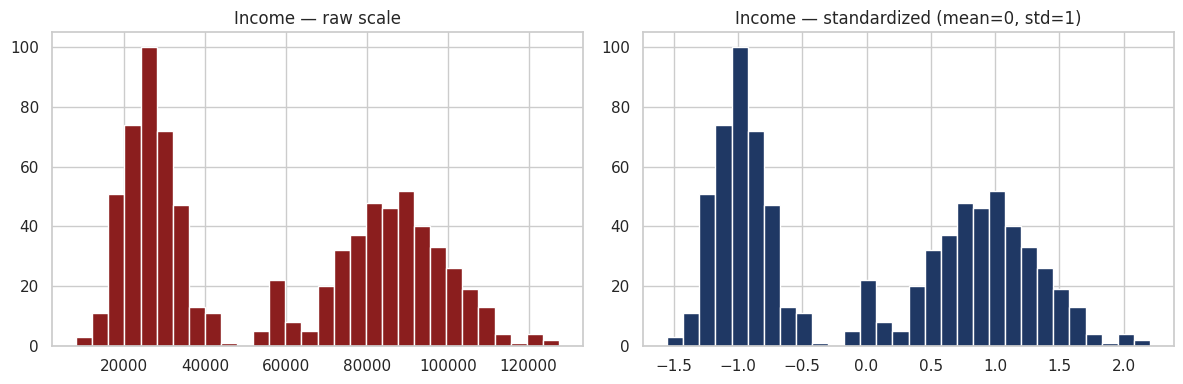

In [6]:
X_scaled, scaler = scale_features(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X["income"], bins=30, color="#8b1e1e")
axes[0].set_title("Income — raw scale")
axes[1].hist(X_scaled[:, X.columns.get_loc("income")], bins=30, color="#1f3864")
axes[1].set_title("Income — standardized (mean=0, std=1)")
plt.tight_layout()
plt.show()


## 3. Phase 2 — COMPRESS (PCA)
With 20+ correlated behavioral columns, we're in the "curse of dimensionality": in high-dimensional space, points become
nearly equidistant and clustering degrades. **Principal Component Analysis (PCA)** finds the orthogonal axes of maximum
variance and projects the data onto a much smaller number of components — like a shadow that preserves the widest spread
of the original signal. We keep however many components are needed to retain **95% of cumulative explained variance**.

Original dimensions: 20
Components retained for 95% variance: 12


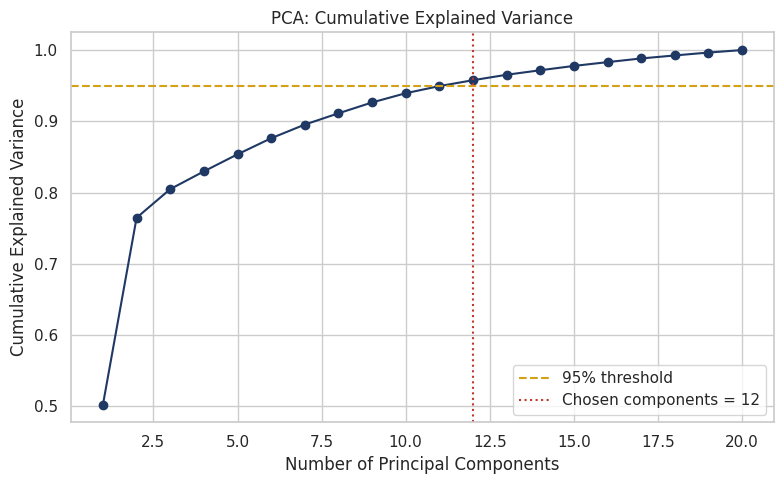

In [7]:
X_pca, pca, pca_full, cum_var, n_components = run_pca(X_scaled, variance_threshold=0.95)

print(f"Original dimensions: {X_scaled.shape[1]}")
print(f"Components retained for 95% variance: {n_components}")

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(1, len(cum_var) + 1)
ax.plot(x, cum_var, marker="o", color="#1f3864")
ax.axhline(0.95, color="#d4a017", linestyle="--", label="95% threshold")
ax.axvline(n_components, color="#c0392b", linestyle=":", label=f"Chosen components = {n_components}")
ax.set_xlabel("Number of Principal Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("PCA: Cumulative Explained Variance")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Phase 3 — CLUSTER (K-Means)
K-Means minimizes the **Within-Cluster Sum of Squares (WCSS)**: `Σ ||x - μ_k||²`. It cannot tell us how many clusters
*should* exist — we have to prove that with two diagnostic gatekeepers:

- **Elbow Method** — plot WCSS vs. K; the "elbow" is the point of diminishing returns.
- **Silhouette Score** — measures cohesion vs. separation, from -1 (wrong cluster) to +1 (well-separated).

We test K from 2 to 10 and combine both diagnostics to pick a final, business-usable K.

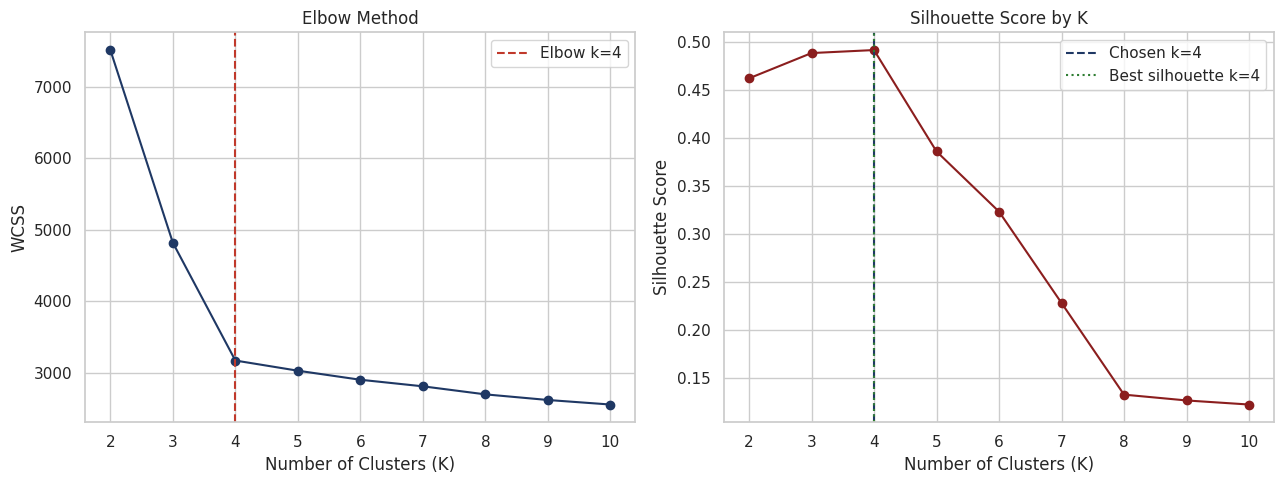

Final K selected: 4


In [8]:
k_values, wcss, sil_scores = evaluate_k_range(X_pca, k_range=range(2, 11))

elbow_k = find_elbow_k(k_values, wcss)
final_k = choose_final_k(k_values, wcss, sil_scores)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_values, wcss, marker="o", color="#1f3864")
axes[0].axvline(elbow_k, color="#c0392b", linestyle="--", label=f"Elbow k={elbow_k}")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("WCSS")
axes[0].set_title("Elbow Method")
axes[0].legend()

axes[1].plot(k_values, sil_scores, marker="o", color="#8b1e1e")
best_sil_k = k_values[int(np.argmax(sil_scores))]
axes[1].axvline(final_k, color="#1f3864", linestyle="--", label=f"Chosen k={final_k}")
axes[1].axvline(best_sil_k, color="#2e7d32", linestyle=":", label=f"Best silhouette k={best_sil_k}")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by K")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Final K selected: {final_k}")


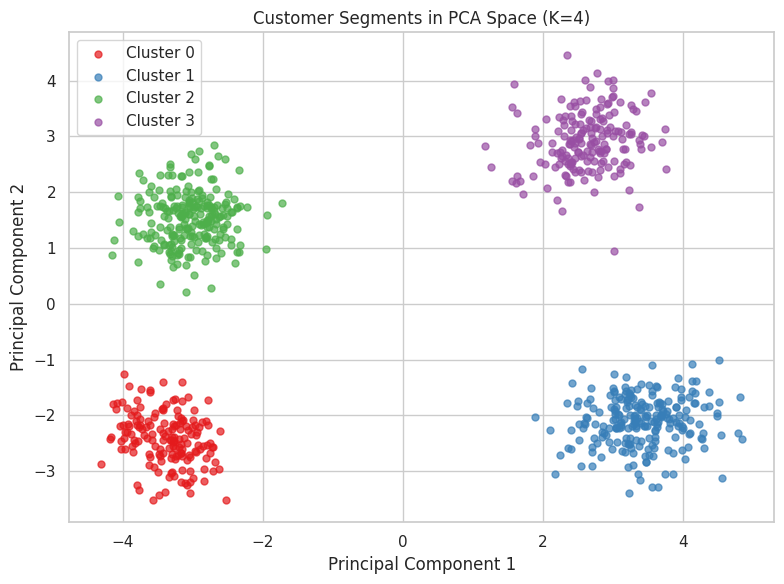

In [9]:
km, labels = fit_final_kmeans(X_pca, final_k)
df["cluster"] = labels

fig, ax = plt.subplots(figsize=(8, 6))
palette = sns.color_palette("Set1", final_k)
for cluster_id in range(final_k):
    mask = labels == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=25, alpha=0.7,
               color=palette[cluster_id], label=f"Cluster {cluster_id}")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title(f"Customer Segments in PCA Space (K={final_k})")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Phase 4 — TRANSLATE (Business Personas)
K-Means was fit in abstract PCA space, which means nothing to a marketing team. We map cluster membership back onto the
**original, unscaled** feature values (age, income, spending score, etc.) to build interpretable personas, then apply
simple business rules (income vs. spending score quadrant) to name and act on each segment.

In [10]:
persona = build_persona_table(X, labels)
persona_names = label_personas(persona)
persona["persona_name"] = persona.index.map(persona_names)
persona["recommended_action"] = persona["persona_name"].map(PERSONA_ACTIONS)
df["persona_name"] = df["cluster"].map(persona_names)

persona[["customer_count", "pct_of_base", "persona_name", "age", "income",
         "spending_score", "annual_purchases", "recommended_action"]]


,customer_count,pct_of_base,persona_name,age,income,spending_score,annual_purchases,recommended_action
cluster,,,,,,,,
0,163,20.4,Conservative Minimizers,45.59,27746.16,20.30,3.13,"Minimize acquisition spend, clear price/value ..."
1,228,28.5,Budget-Conscious Explorers,24.96,26392.05,79.01,21.57,"Influencer campaigns, flash sales, buy-now-pay..."
2,230,28.7,Affluent Conservatives,40.85,87607.74,17.51,5.94,"High-touch support, extended warranties, loyal..."
3,179,22.4,High-Value Trendsetters,32.63,85159.81,81.00,28.30,"Exclusive perks, early access, experiential ma..."


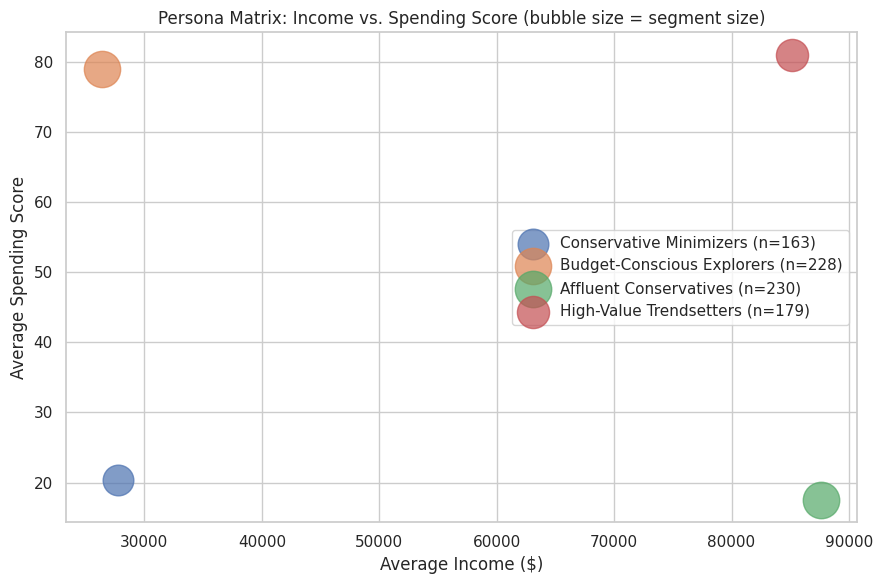

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
for cluster_id in range(final_k):
    row = persona.loc[cluster_id]
    ax.scatter(row["income"], row["spending_score"], s=row["customer_count"] * 3,
               alpha=0.7, label=f"{row['persona_name']} (n={int(row['customer_count'])})")
ax.set_xlabel("Average Income ($)")
ax.set_ylabel("Average Spending Score")
ax.set_title("Persona Matrix: Income vs. Spending Score (bubble size = segment size)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


## 6. Persona Playbook

| Persona | Profile | Recommended Action |
|---|---|---|
| **Affluent Conservatives** | Older, high income, low spending score | High-touch support, extended warranties, loyalty programs |
| **High-Value Trendsetters** | Mid-30s, high income, high spending score | Exclusive perks, early access, experiential marketing |
| **Budget-Conscious Explorers** | Young, low income, high spending score | Influencer campaigns, flash sales, buy-now-pay-later |
| **Conservative Minimizers** | Older, low income, low spending score | Minimize acquisition spend, clear price/value messaging |

## 7. Save outputs

In [12]:
df.to_csv("../outputs/customers_with_segments.csv", index=False)
persona.to_csv("../outputs/persona_summary.csv")
print("Saved customers_with_segments.csv and persona_summary.csv to /outputs")


Saved customers_with_segments.csv and persona_summary.csv to /outputs


## Conclusion
Starting from 20+ unlabeled behavioral columns, this pipeline:

1. Standardized features to remove scale bias.
2. Used PCA to compress the feature space to `{n_components}` components while retaining 95% of variance.
3. Mathematically justified K={final_k} clusters using the Elbow Method and Silhouette Score.
4. Reverse-engineered cluster centroids into four actionable, human-readable business personas.

This distance-based approach generalizes to real-time recommendation engines, marketing-spend optimization, and any
scenario where raw behavioral noise needs to become strategic action.
